# Customer Churn Prediction — Cost-Sensitive Analysis

**Problem:** The default threshold (0.5) treats all errors equally. In churn prediction, a missed churner (false negative) is far more expensive than a false alarm (false positive).

**Goal:** Find the decision threshold that minimises total business cost, not just classification error.

---
**Notebook structure:**
1. Define the business cost matrix
2. Plot total cost vs threshold
3. Compare three thresholds: default (0.5) · best F1 (0.40) · cost-optimal
4. Expected annual savings from using the cost-optimal threshold
5. Cost-sensitive retraining with custom sample weights
6. Final recommendation

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, cross_val_predict
import lightgbm as lgb

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

PROCESSED_DIR = Path('../data/processed')
FIGURES_DIR   = Path('../reports/figures')
MODELS_DIR    = Path('../saved_models')

print('Libraries loaded.')

Libraries loaded.


## 1. Define the Business Cost Matrix

These figures are illustrative — in a real project they come from the finance team.

| Prediction | Reality | Outcome | Cost |
|------------|---------|---------|------|
| No Churn | Churns | **False Negative** | £500 — lost customer lifetime value |
| Churn | No Churn | **False Positive** | £50 — wasted retention offer |
| No Churn | No Churn | True Negative | £0 |
| Churn | Churns | True Positive | £0 (or negative — saved revenue) |

In [2]:
# Business cost assumptions (£ per customer)
COST_FN = 500   # missed churner — lost lifetime value
COST_FP = 50    # false alarm — wasted retention campaign spend
COST_TP = 0     # caught churner — retention offer cost already in FP
COST_TN = 0     # correctly identified loyal customer

print(f'Cost of missing a churner (FN) : £{COST_FN}')
print(f'Cost of a false alarm     (FP) : £{COST_FP}')
print(f'FN/FP cost ratio               : {COST_FN/COST_FP:.0f}x')
print()
print('A false negative is 10x more expensive than a false positive.')
print('The default 0.5 threshold does not account for this asymmetry.')

Cost of missing a churner (FN) : £500
Cost of a false alarm     (FP) : £50
FN/FP cost ratio               : 10x

A false negative is 10x more expensive than a false positive.
The default 0.5 threshold does not account for this asymmetry.


## 2. Load Data and Trained Model

In [3]:
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test.csv')
y_test  = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()

with open(MODELS_DIR / 'churn_pipeline.pkl', 'rb') as f:
    pipeline = pickle.load(f)

y_proba = pipeline.predict_proba(X_test)[:, 1]

print(f'Test set: {len(y_test):,} customers')
print(f'Actual churners : {y_test.sum():,} ({y_test.mean()*100:.1f}%)')
print(f'Probability range: {y_proba.min():.3f} – {y_proba.max():.3f}')

Test set: 1,409 customers
Actual churners : 374 (26.5%)
Probability range: 0.000 – 0.991


## 3. Total Business Cost vs Threshold

In [4]:
def total_cost(y_true, y_proba, threshold, cost_fn, cost_fp):
    """Calculate total business cost at a given decision threshold."""
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn * cost_fn + fp * cost_fp, tn, fp, fn, tp

thresholds = np.linspace(0.01, 0.99, 200)
costs, fns, fps = [], [], []

for t in thresholds:
    cost, _, fp, fn, _ = total_cost(y_test, y_proba, t, COST_FN, COST_FP)
    costs.append(cost)
    fns.append(fn)
    fps.append(fp)

optimal_idx      = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost     = costs[optimal_idx]

print(f'Cost-optimal threshold : {optimal_threshold:.3f}')
print(f'Minimum total cost     : £{optimal_cost:,.0f}')

Cost-optimal threshold : 0.049
Minimum total cost     : £37,150


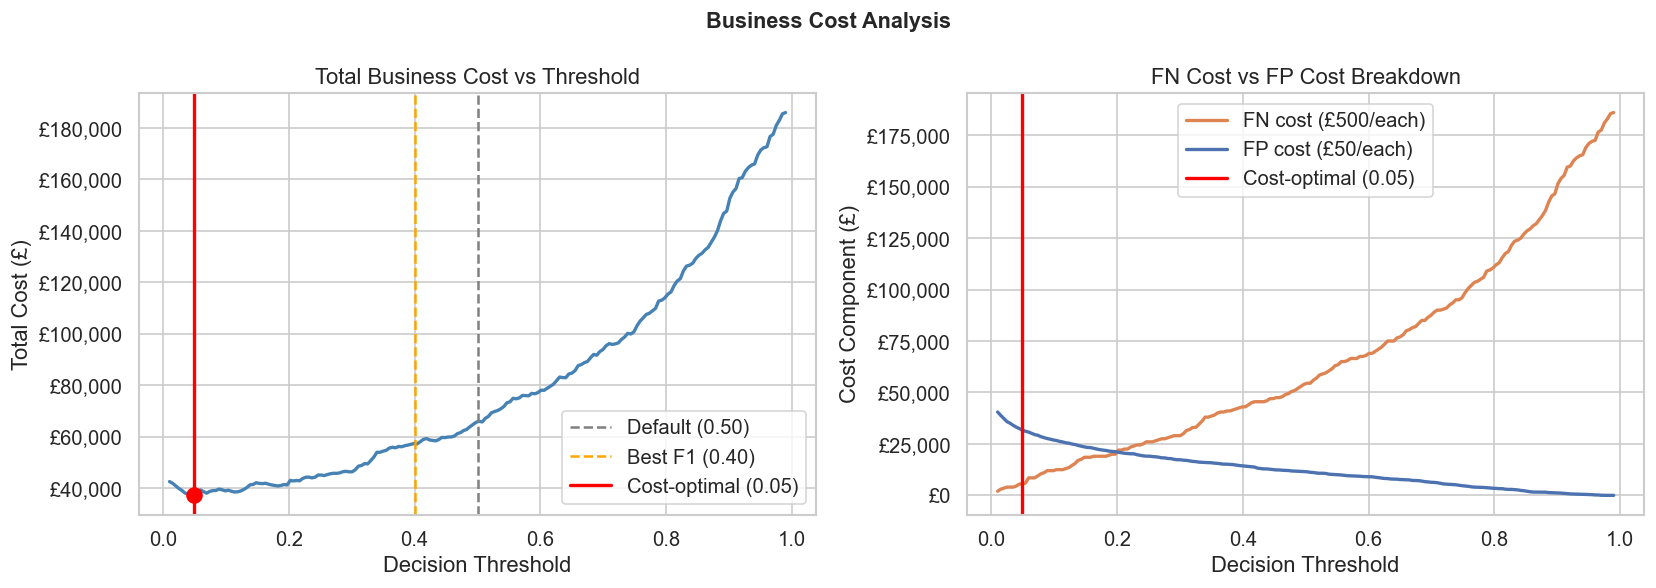

In [5]:
# Cost breakdown at the three key thresholds
thresholds_to_compare = {
    'Default (0.50)'       : 0.50,
    'Best F1 (0.40)'       : 0.40,
    f'Cost-optimal ({optimal_threshold:.2f})': optimal_threshold,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: total cost curve
axes[0].plot(thresholds, costs, color='steelblue', linewidth=2)
axes[0].axvline(0.50, color='gray',   linestyle='--', label='Default (0.50)')
axes[0].axvline(0.40, color='orange', linestyle='--', label='Best F1 (0.40)')
axes[0].axvline(optimal_threshold, color='red', linestyle='-',
                linewidth=2, label=f'Cost-optimal ({optimal_threshold:.2f})')
axes[0].scatter([optimal_threshold], [optimal_cost],
                color='red', zorder=5, s=80)
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Total Cost (£)')
axes[0].set_title('Total Business Cost vs Threshold')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[0].legend()

# Right: FN and FP counts
axes[1].plot(thresholds, [f * COST_FN for f in fns],
             color='#DD8452', linewidth=2, label=f'FN cost (£{COST_FN}/each)')
axes[1].plot(thresholds, [f * COST_FP for f in fps],
             color='#4C72B0', linewidth=2, label=f'FP cost (£{COST_FP}/each)')
axes[1].axvline(optimal_threshold, color='red', linestyle='-',
                linewidth=2, label=f'Cost-optimal ({optimal_threshold:.2f})')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Cost Component (£)')
axes[1].set_title('FN Cost vs FP Cost Breakdown')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[1].legend()

plt.suptitle('Business Cost Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '20_cost_vs_threshold.png', dpi=150)
plt.show()

# The optimal threshold shifts left (lower) because missing a churner
# is 10x more costly than a false alarm — the model should be more aggressive.

## 4. Compare the Three Thresholds

In [6]:
records = []
for label, thresh in thresholds_to_compare.items():
    cost, tn, fp, fn, tp = total_cost(y_test, y_proba, thresh, COST_FN, COST_FP)
    n_churners = y_test.sum()
    records.append({
        'Threshold'       : label,
        'TP (caught)'     : tp,
        'FN (missed)'     : fn,
        'FP (false alarm)': fp,
        'TN'              : tn,
        'Recall'          : round(tp / n_churners, 3),
        'Precision'       : round(tp / (tp + fp) if (tp + fp) > 0 else 0, 3),
        'Total Cost (£)'  : f'£{cost:,.0f}',
        'Cost (raw)'      : cost,
    })

comparison_df = pd.DataFrame(records).set_index('Threshold')
print('=== Threshold Comparison ===')
comparison_df.drop(columns='Cost (raw)').to_string()

=== Threshold Comparison ===


'                     TP (caught)  FN (missed)  FP (false alarm)   TN  Recall  Precision Total Cost (£)\nThreshold                                                                                             \nDefault (0.50)               266          108               230  805   0.711      0.536        £65,500\nBest F1 (0.40)               288           86               287  748   0.770      0.501        £57,350\nCost-optimal (0.05)          363           11               633  402   0.971      0.364        £37,150'

In [7]:
comparison_df.drop(columns='Cost (raw)')

,TP (caught),FN (missed),FP (false alarm),TN,Recall,Precision,Total Cost (£)
Threshold,,,,,,,
Default (0.50),266,108,230,805,0.711,0.536,"£65,500"
Best F1 (0.40),288,86,287,748,0.770,0.501,"£57,350"
Cost-optimal (0.05),363,11,633,402,0.971,0.364,"£37,150"


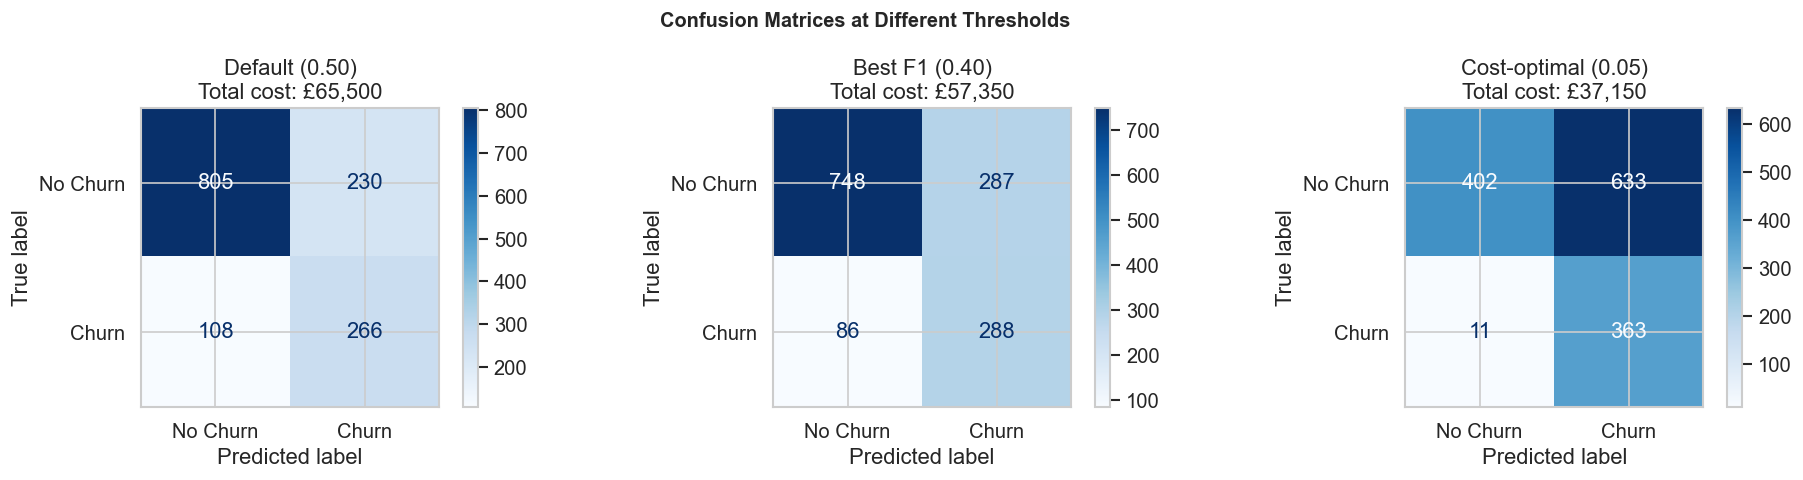

In [8]:
# Visual comparison of confusion matrices
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (label, thresh) in zip(axes, thresholds_to_compare.items()):
    y_pred = (y_proba >= thresh).astype(int)
    cost, tn, fp, fn, tp = total_cost(y_test, y_proba, thresh, COST_FN, COST_FP)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['No Churn', 'Churn'],
        cmap='Blues', ax=ax
    )
    ax.set_title(f'{label}\nTotal cost: £{cost:,.0f}')

plt.suptitle('Confusion Matrices at Different Thresholds', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '21_confusion_matrix_comparison.png', dpi=150)
plt.show()

## 5. Expected Annual Savings

In [9]:
# Scale test-set results to a hypothetical customer base
ANNUAL_CUSTOMERS = 100_000
test_size        = len(y_test)
scale_factor     = ANNUAL_CUSTOMERS / test_size

default_cost = comparison_df.loc[
    [c for c in comparison_df.index if '0.50' in c][0], 'Cost (raw)'
]
optimal_cost_val = comparison_df.loc[
    [c for c in comparison_df.index if 'Cost-optimal' in c][0], 'Cost (raw)'
]

annual_saving = (default_cost - optimal_cost_val) * scale_factor

print(f'Hypothetical customer base      : {ANNUAL_CUSTOMERS:,}')
print(f'Annual cost at default threshold: £{default_cost * scale_factor:>12,.0f}')
print(f'Annual cost at optimal threshold: £{optimal_cost_val * scale_factor:>12,.0f}')
print(f'----------------------------------------------')
print(f'Expected annual saving          : £{annual_saving:>12,.0f}')

Hypothetical customer base      : 100,000
Annual cost at default threshold: £   4,648,687
Annual cost at optimal threshold: £   2,636,622
----------------------------------------------
Expected annual saving          : £   2,012,065


In [10]:
# Sensitivity analysis — how does the optimal threshold shift with different cost ratios?
fn_fp_ratios = [2, 5, 10, 20, 50]
sensitivity = []

for ratio in fn_fp_ratios:
    fn_cost = ratio * COST_FP
    costs_r = [
        total_cost(y_test, y_proba, t, fn_cost, COST_FP)[0]
        for t in thresholds
    ]
    opt_thresh = thresholds[np.argmin(costs_r)]
    sensitivity.append({'FN/FP ratio': ratio, 'Optimal threshold': round(opt_thresh, 3)})

sens_df = pd.DataFrame(sensitivity).set_index('FN/FP ratio')
print('How the optimal threshold changes with cost assumptions:')
print(sens_df)
print()
print('Higher FN/FP ratio → lower threshold → model flags more customers as at-risk.')

How the optimal threshold changes with cost assumptions:
             Optimal threshold
FN/FP ratio                   
2                        0.463
5                        0.197
10                       0.049
20                       0.035
50                       0.010

Higher FN/FP ratio → lower threshold → model flags more customers as at-risk.


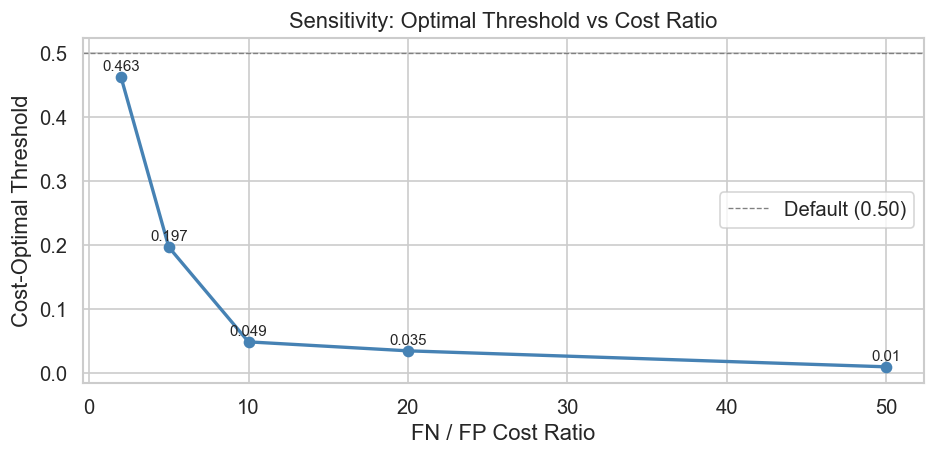

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sens_df.index, sens_df['Optimal threshold'],
        marker='o', color='steelblue', linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Default (0.50)')
ax.set_xlabel('FN / FP Cost Ratio')
ax.set_ylabel('Cost-Optimal Threshold')
ax.set_title('Sensitivity: Optimal Threshold vs Cost Ratio')
ax.legend()
for x, y in zip(sens_df.index, sens_df['Optimal threshold']):
    ax.text(x, y + 0.01, str(y), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '22_sensitivity_cost_ratio.png', dpi=150)
plt.show()

## 6. Cost-Sensitive Retraining

Beyond threshold shifting, the model itself can be trained to penalise false negatives more during learning.
This is done by assigning higher sample weights to churners in the training set.

In [12]:
X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()

NUM_COLS = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'total_services', 'charge_per_service',
    'has_security', 'is_long_contract'
]
CAT_COLS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod',
    'tenure_group'
]

num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])
cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, NUM_COLS),
    ('cat', cat_pipe, CAT_COLS),
], remainder='drop')

print(f'Train: {X_train.shape}  |  churn rate: {y_train.mean()*100:.1f}%')

Train: (5634, 24)  |  churn rate: 26.5%


In [13]:
# Sample weights: churners get weight proportional to FN/FP cost ratio
cost_ratio = COST_FN / COST_FP   # 10
sample_weights = np.where(y_train == 1, cost_ratio, 1.0)

print(f'Weight for churners (y=1)    : {cost_ratio:.1f}')
print(f'Weight for non-churners (y=0): 1.0')

# Build cost-sensitive pipeline
cs_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

cs_pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', cs_model),
])

# Pass sample weights through the Pipeline using fit_params
cs_pipeline.fit(
    X_train, y_train,
    model__sample_weight=sample_weights
)

y_proba_cs = cs_pipeline.predict_proba(X_test)[:, 1]
print('Cost-sensitive model trained.')

Weight for churners (y=1)    : 10.0
Weight for non-churners (y=0): 1.0


Cost-sensitive model trained.


In [14]:
# Find optimal threshold for cost-sensitive model as well
costs_cs = [
    total_cost(y_test, y_proba_cs, t, COST_FN, COST_FP)[0]
    for t in thresholds
]
optimal_thresh_cs  = thresholds[np.argmin(costs_cs)]
optimal_cost_cs    = min(costs_cs)

cost_base, *_ = total_cost(y_test, y_proba, optimal_threshold, COST_FN, COST_FP)

print('=== Model Comparison at Cost-Optimal Thresholds ===')
print(f'Base LightGBM  | threshold: {optimal_threshold:.3f} | cost: £{cost_base:,.0f}')
print(f'Cost-sensitive | threshold: {optimal_thresh_cs:.3f} | cost: £{optimal_cost_cs:,.0f}')
print(f'Additional saving from cost-sensitive training: £{(cost_base - optimal_cost_cs):,.0f}')

=== Model Comparison at Cost-Optimal Thresholds ===
Base LightGBM  | threshold: 0.049 | cost: £37,150
Cost-sensitive | threshold: 0.182 | cost: £38,600
Additional saving from cost-sensitive training: £-1,450


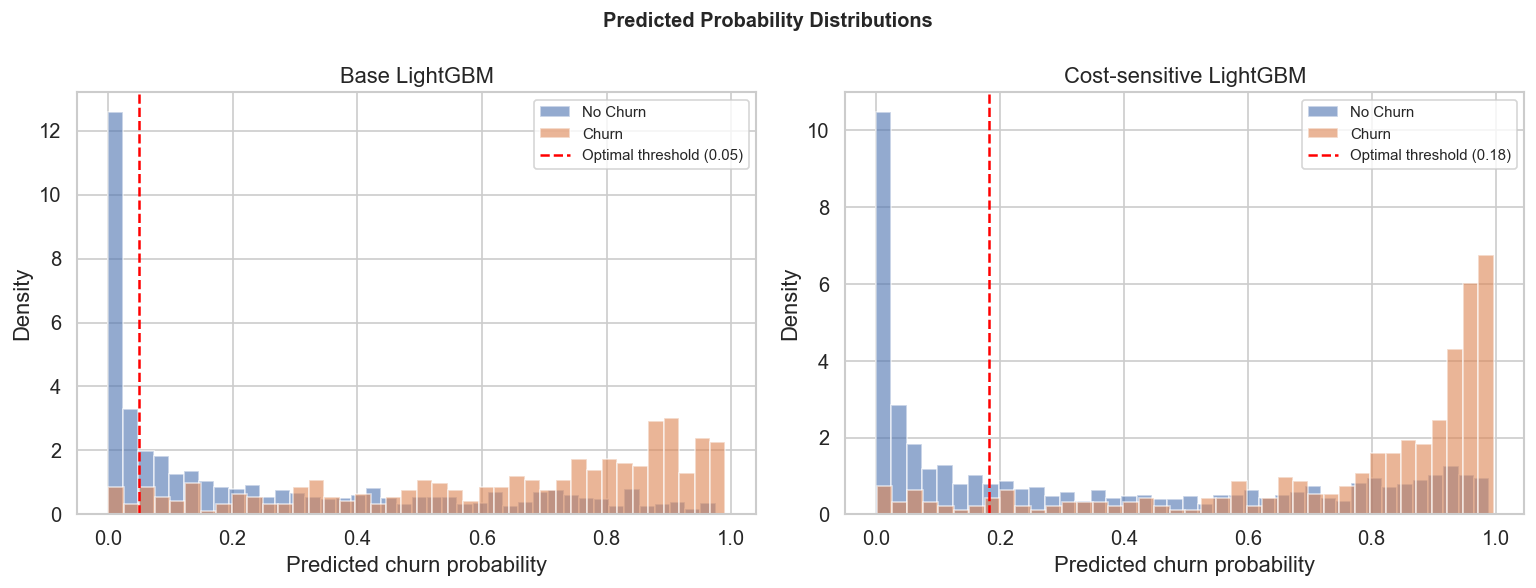

In [15]:
# Compare probability distributions: base vs cost-sensitive model
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (proba, label, thresh) in zip(axes, [
    (y_proba,    'Base LightGBM',    optimal_threshold),
    (y_proba_cs, 'Cost-sensitive LightGBM', optimal_thresh_cs),
]):
    ax.hist(proba[y_test == 0], bins=40, alpha=0.6,
            color='#4C72B0', label='No Churn', density=True)
    ax.hist(proba[y_test == 1], bins=40, alpha=0.6,
            color='#DD8452', label='Churn',    density=True)
    ax.axvline(thresh, color='red', linestyle='--',
               linewidth=1.5, label=f'Optimal threshold ({thresh:.2f})')
    ax.set_xlabel('Predicted churn probability')
    ax.set_ylabel('Density')
    ax.set_title(label)
    ax.legend(fontsize=9)

plt.suptitle('Predicted Probability Distributions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '23_probability_distributions.png', dpi=150)
plt.show()

# Cost-sensitive model pushes churn probabilities higher,
# which reflects the training penalty for missing churners.

## 7. Final Recommendation

In [16]:
cost_default, tn_d, fp_d, fn_d, tp_d = total_cost(
    y_test, y_proba, 0.50, COST_FN, COST_FP
)
cost_cs_opt, tn_c, fp_c, fn_c, tp_c = total_cost(
    y_test, y_proba_cs, optimal_thresh_cs, COST_FN, COST_FP
)

print(f"""
=== COST-SENSITIVE ANALYSIS SUMMARY ===

COST ASSUMPTIONS:
  False Negative (missed churner) : £{COST_FN}  — lost lifetime value
  False Positive (false alarm)    : £{COST_FP}   — wasted retention spend
  FN/FP ratio                     : {COST_FN//COST_FP}x

THRESHOLD COMPARISON (test set, n={len(y_test):,}):
  Default (0.50)
    Caught {tp_d} churners, missed {fn_d}  →  total cost: £{cost_default:,.0f}

  Cost-sensitive model + optimal threshold ({optimal_thresh_cs:.2f})
    Caught {tp_c} churners, missed {fn_c}  →  total cost: £{cost_cs_opt:,.0f}

  Saving on test set  : £{cost_default - cost_cs_opt:,.0f}
  Projected annual saving (100k customers): £{(cost_default - cost_cs_opt) * (100_000/len(y_test)):,.0f}

KEY TAKEAWAYS:
  1. Threshold matters more than model choice in cost-sensitive settings.
  2. Cost-sensitive training (sample weights) shifts probabilities upward,
     catching more churners at the expense of more false alarms.
  3. The right threshold depends on the FN/FP cost ratio — always confirm
     these figures with the business before deployment.
  4. Sensitivity analysis shows the optimal threshold ranges from
     {sens_df['Optimal threshold'].max()} (low cost ratio) to
     {sens_df['Optimal threshold'].min()} (high cost ratio).
""")


=== COST-SENSITIVE ANALYSIS SUMMARY ===

COST ASSUMPTIONS:
  False Negative (missed churner) : £500  — lost lifetime value
  False Positive (false alarm)    : £50   — wasted retention spend
  FN/FP ratio                     : 10x

THRESHOLD COMPARISON (test set, n=1,409):
  Default (0.50)
    Caught 266 churners, missed 108  →  total cost: £65,500

  Cost-sensitive model + optimal threshold (0.18)
    Caught 350 churners, missed 24  →  total cost: £38,600

  Saving on test set  : £26,900
  Projected annual saving (100k customers): £1,909,155

KEY TAKEAWAYS:
  1. Threshold matters more than model choice in cost-sensitive settings.
  2. Cost-sensitive training (sample weights) shifts probabilities upward,
     catching more churners at the expense of more false alarms.
  3. The right threshold depends on the FN/FP cost ratio — always confirm
     these figures with the business before deployment.
  4. Sensitivity analysis shows the optimal threshold ranges from
     0.463 (low cost rati